# Plot QIs as histogram

- check overall distribution of the QIs
- plot them as histogram for that

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datajoint as dj
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Create access to djimaging database

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-11-11 13:17:07,995][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-11-11 13:17:08,075][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

## Activate Schema

In [12]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Plotting

## 23.10.2025
### Stimuli and Condition

In [13]:
date = datetime.date(2025, 10, 23)
stimulus = "gChirp"

In [17]:
ChirpQI() & {"date": date, "stim_name": stimulus, "cond2": "C1"}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,1,1,0.190383,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,2,1,0.268426,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,3,1,0.32174,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,4,1,0.348374,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,5,1,0.440524,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,6,1,0.312994,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,7,1,0.335758,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,8,1,0.335647,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,9,1,0.312693,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,10,1,0.381247,0.2


In [18]:
quality_indices = (ChirpQI() & {"date": date, "stim_name": stimulus, "cond2": "C1"}).fetch("qidx")
quality_indices

array([0.190383, 0.268426, 0.32174 , ..., 0.319786, 0.181248, 0.548765],
      shape=(1340,))

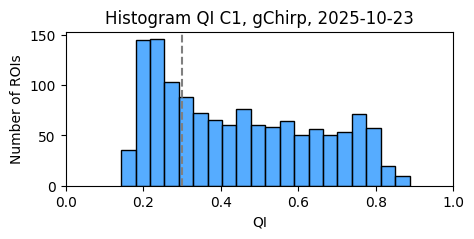

In [36]:
fig, axs = plt.subplots(figsize=(5,2))

sns.histplot(quality_indices, bins=20, color="dodgerblue")

axs.set_xlim(0, 1)
axs.set_title(f"Histogram QI C1, {stimulus}, {date}")
axs.set_ylabel("Number of ROIs")
axs.set_xlabel("QI")
axs.axvline(0.3, color="gray", linestyle="--", linewidth=1.5)

In [39]:
conditions = (ChirpQI() & {"date": date}).fetch("cond2")
conditions = np.unique(conditions)
conditions

array(['C1', 'C2', 'DETANO'], dtype=object)

In [60]:
stimuli = (Averages() & {"date": date}).fetch("stim_name")
stimuli = np.unique(stimuli)
stimuli

array(['gChirp', 'lChirp', 'movingbar'], dtype=object)

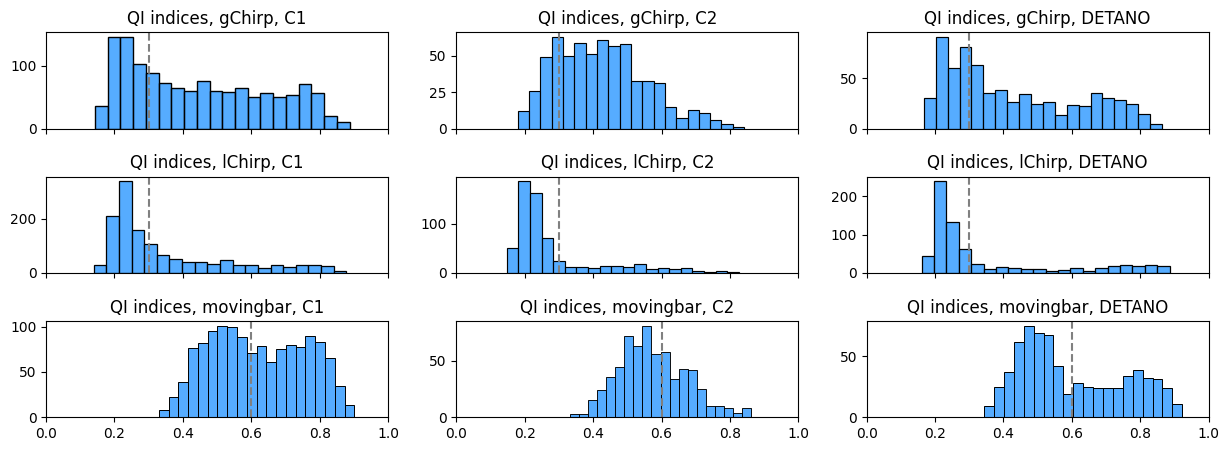

In [109]:
fig, axs = plt.subplots(3, 3, figsize=(15, 5), sharex=True)

plt.subplots_adjust(hspace=0.5)

for i, condition in enumerate(conditions):

    for j, stimulus in enumerate(stimuli):

        if stimulus=="movingbar":

            quality_indices = (OsDsIndexes() & {"date": date, "stim_name": stimulus, "cond2": condition}).fetch("d_qi")

        else:
        
            quality_indices = (ChirpQI() & {"date": date, "stim_name": stimulus, "cond2": condition}).fetch("qidx")

        sns.histplot(quality_indices, bins=20, color="dodgerblue", ax=axs[j, i])

        if stimulus=="movingbar":
            axs[j, i].axvline(0.6, color="gray", linestyle="--", linewidth=1.5)

        else:
            axs[j, i].axvline(0.3, color="gray", linestyle="--", linewidth=1.5)

        axs[j, i].set_title(f"QI indices, {stimulus}, {condition}")
        axs[j, i].set_ylabel("")
        axs[j, i].set_xlim(0, 1)
        
        #print(condition, stimulus)
        #print(j, i)
        #print(quality_indices)

plt.savefig("plots/20251023/quality/histogram_parameter_stimulus_condition.png",
            dpi=300,
            bbox_inches="tight")

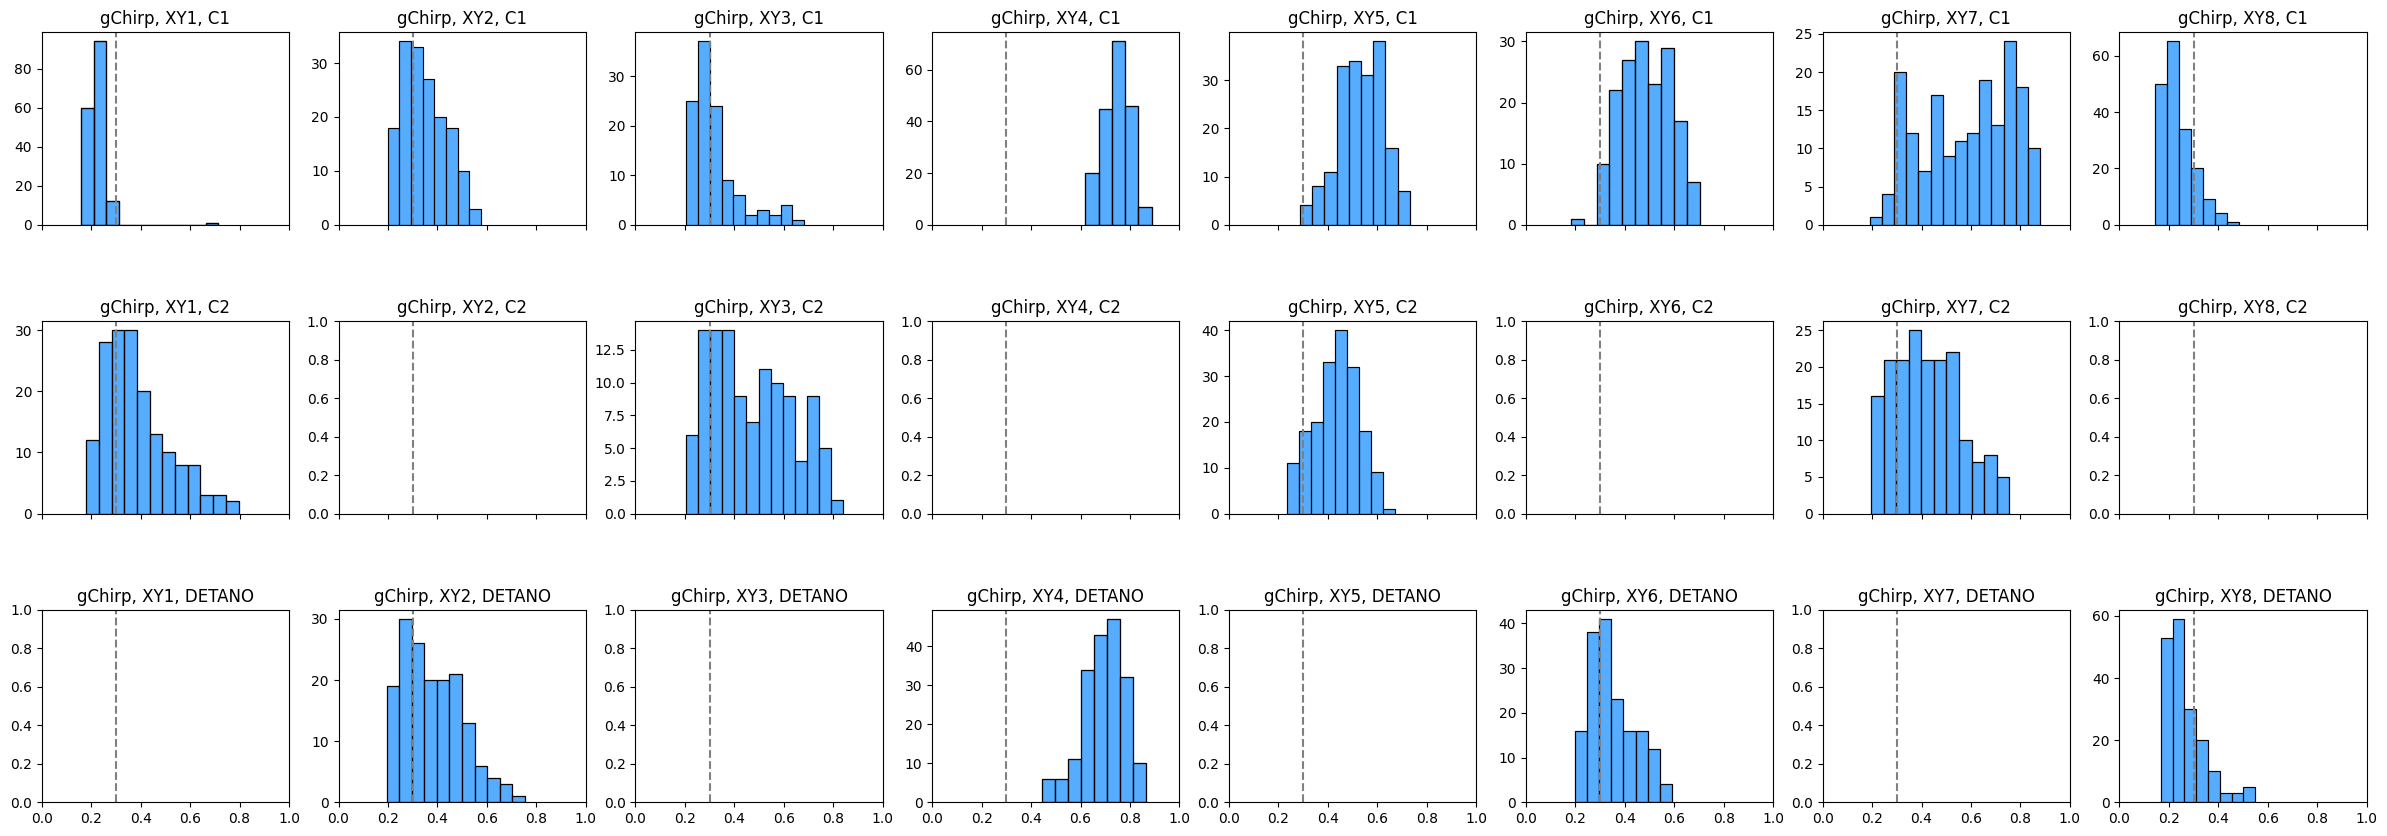

In [108]:
stimulus = "gChirp"

fig, axs = plt.subplots(3, 8, figsize=(30, 10), sharex=True)

plt.subplots_adjust(hspace=0.5)

for i, field in enumerate(fields):

    for j, condition in enumerate(conditions):

        if stimulus=="movingbar":

            quality_indices = (OsDsIndexes() & {"date": date, "stim_name": stimulus, "cond2": condition, "field": field}).fetch("d_qi")

        else:
        
            quality_indices = (ChirpQI() & {"date": date, "stim_name": stimulus, "cond2": condition, "field": field}).fetch("qidx")

        sns.histplot(quality_indices, color="dodgerblue", ax=axs[j, i], binwidth=0.05)

        if stimulus=="movingbar":
            axs[j, i].axvline(0.6, color="gray", linestyle="--", linewidth=1.5)

        else:
            axs[j, i].axvline(0.3, color="gray", linestyle="--", linewidth=1.5)

        axs[j, i].set_title(f"{stimulus}, {field}, {condition}")
        axs[j, i].set_ylabel("")
        axs[j, i].set_xlim(0, 1)
        
        # print(i, j)
        # print(field, stimulus)

plt.savefig(f"plots/20251023/quality/histogram_{stimulus}_all_fields.png",
            dpi=300,
            bbox_inches="tight")

### Stimuli, Condtion, and Field

In [64]:
fields = (Averages() & {"date": date}).fetch("field")
fields = np.unique(fields)
fields

array(['XY1', 'XY2', 'XY3', 'XY4', 'XY5', 'XY6', 'XY7', 'XY8'],
      dtype=object)

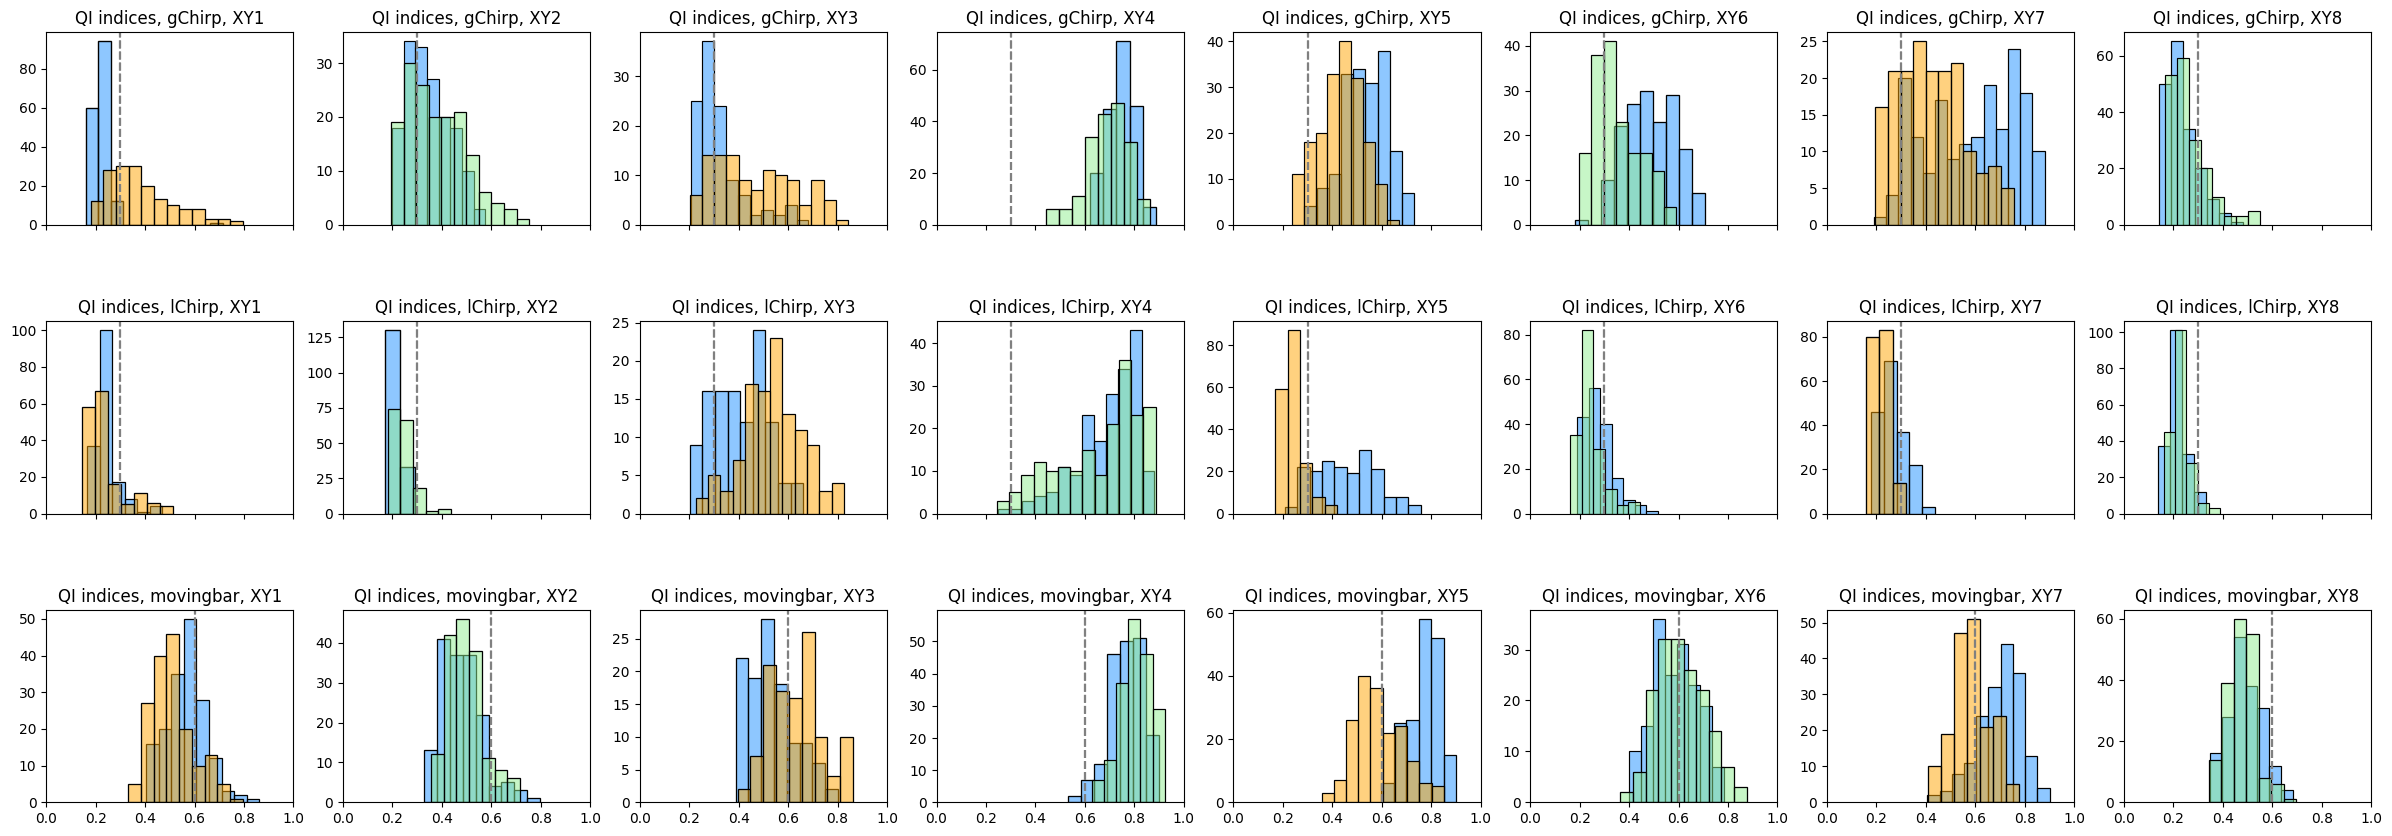

In [104]:
fig, axs = plt.subplots(3, 8, figsize=(30, 10), sharex=True)

plt.subplots_adjust(hspace=0.5)

for h, condition in enumerate(conditions):

    for i, field in enumerate(fields):
    
        for j, stimulus in enumerate(stimuli):
    
            if stimulus=="movingbar":
    
                quality_indices = (OsDsIndexes() & {"date": date, "stim_name": stimulus, "cond2": condition, "field": field}).fetch("d_qi")
    
            else:
            
                quality_indices = (ChirpQI() & {"date": date, "stim_name": stimulus, "cond2": condition, "field": field}).fetch("qidx")
    
            if condition=="C1":
                sns.histplot(quality_indices, binwidth=0.05, color="dodgerblue", ax=axs[j, i], alpha=0.5)
            elif condition=="C2":
                sns.histplot(quality_indices, binwidth=0.05, color="orange", ax=axs[j, i], alpha=0.5)
            elif condition=="DETANO":
                sns.histplot(quality_indices, binwidth=0.05, color="lightgreen", ax=axs[j, i], alpha=0.5)
    
            if stimulus=="movingbar":
                axs[j, i].axvline(0.6, color="gray", linestyle="--", linewidth=1.5)
    
            else:
                axs[j, i].axvline(0.3, color="gray", linestyle="--", linewidth=1.5)
    
            axs[j, i].set_title(f"QI indices, {stimulus}, {field}")
            axs[j, i].set_ylabel("")
            axs[j, i].set_xlim(0, 1)
            
            # print(i, j)
            # print(field, stimulus)

plt.savefig("plots/20251023/quality/histogram_all_parameter.png",
            dpi=300,
            bbox_inches="tight")